In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [2]:
!git clone https://github.com/philippwaleria1-blip/steam-ml-project.git

Cloning into 'steam-ml-project'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 40 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 6.19 MiB | 13.10 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [3]:
%cd steam-ml-project

/content/steam-ml-project


In [4]:
os.listdir()

['steam.csv', 'README.md', 'Presentation.pdf', 'ml_steam.ipynb', '.git']

In [5]:
df = pd.read_csv("steam.csv")

In [6]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

(27075, 18)

In [7]:
df.describe()

,appid,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


In [8]:
df.isnull().sum()

,0
appid,0
name,0
release_date,0
english,0
developer,1
publisher,14
platforms,0
required_age,0
categories,0
genres,0


In [9]:
df["developer"] = df["developer"].fillna("Unknown")
df["publisher"] = df["publisher"].fillna("Unknown")

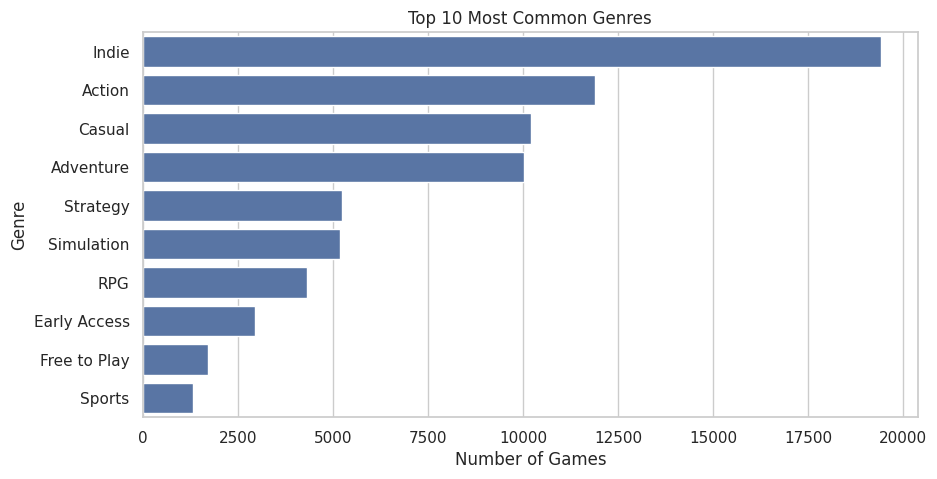

In [10]:
genres = (
    df["genres"]
    .str.split(";")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=genres.values,
    y=genres.index
)

plt.title("Top 10 Most Common Genres")
plt.xlabel("Number of Games")
plt.ylabel("Genre")
plt.show()

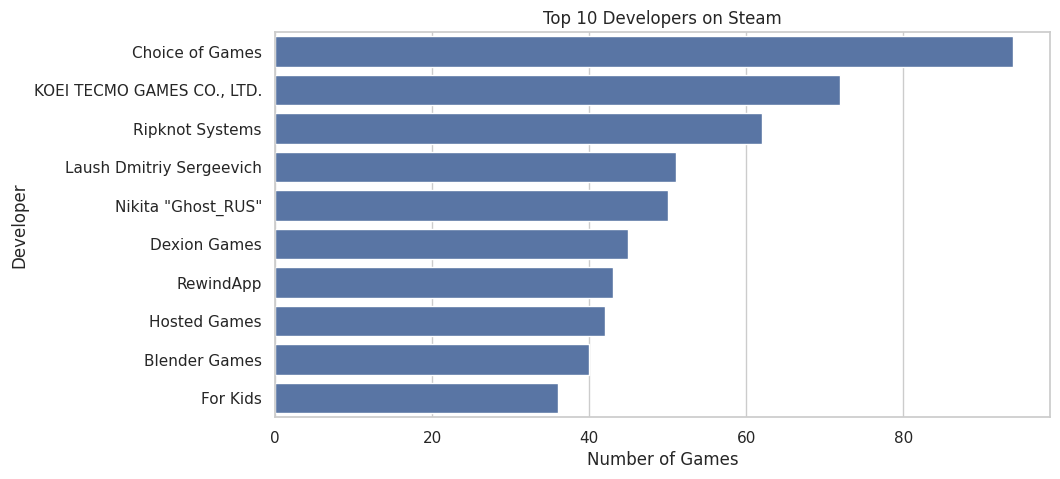

In [11]:
top_developers = df["developer"].value_counts().head(10)
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_developers.values,
    y=top_developers.index
)

plt.title("Top 10 Developers on Steam")
plt.xlabel("Number of Games")
plt.ylabel("Developer")
plt.show()

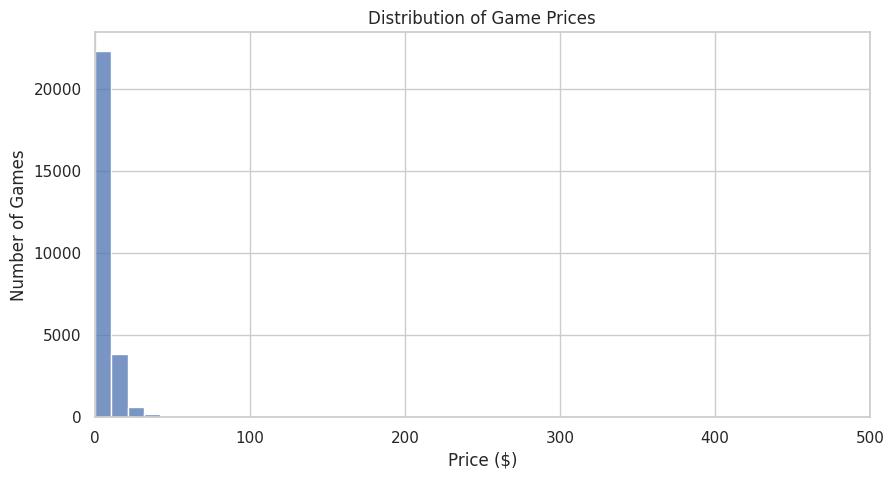

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=40)
plt.title("Distribution of Game Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Games")
plt.xlim(0, 500)
plt.show()

In [13]:
above_60 = df[df["price"] > 60]
print(above_60[["name", "price"]].sort_values(by="price", ascending=True))

                                                    name   price
1854                                          Wing IDE 5   60.99
5384                                        RPG Maker MV   60.99
3950                   AppGameKit: Easy Game Development   60.99
3836         Command: Modern Air / Naval Operations WOTY   60.99
9295       Crazy Stone Deep Learning -The First Edition-   60.99
5672                      Gary Grigsby's War in the East   60.99
14826                     Gary Grigsby's War in the West   60.99
18269                         最強の囲碁 ～名人への道～ / Igo Meijin   62.99
1904                                Clickteam Fusion 2.5   69.99
23709                                        Cine Tracer   69.99
12517                                     articy:draft 3   74.99
13053                         GameMaker Studio 2 Desktop   75.99
12212                                        Emission VR   75.99
2049                               Aartform Curvy 3D 3.0   75.99
18503                    

In [14]:
df["price"] = df["price"].clip(upper=155)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["total_ratings"] = df["positive_ratings"] + df["negative_ratings"]

In [17]:
df["rating_ratio"] = df["positive_ratings"] / (df["positive_ratings"] + df["negative_ratings"])
df["rating_ratio"] = df["rating_ratio"].fillna(0)

In [18]:
df["log_ratings"] = np.log1p(df["total_ratings"])

In [19]:
df["is_free"] = (df["price"] == 0).astype(int)

In [20]:
df[["total_ratings", "rating_ratio", "log_ratings", "is_free"]].head()

,total_ratings,rating_ratio,log_ratings,is_free
0,127873,0.973888,11.758801,0
1,3951,0.839787,8.281977,0
2,3814,0.895648,8.246696,0
3,1540,0.826623,7.340187,0
4,5538,0.947996,8.619569,0


In [21]:
df[["total_ratings", "rating_ratio", "log_ratings", "is_free"]].describe()

,total_ratings,rating_ratio,log_ratings,is_free
count,2.707500e+04,27075.000000,27075.000000,27075.000000
mean,1.211586e+03,0.714478,3.928539,0.094552
std,2.242909e+04,0.233594,2.082908,0.292601
min,1.000000e+00,0.000000,0.693147,0.000000
25%,1.000000e+01,0.583333,2.397895,0.000000
50%,3.600000e+01,0.760331,3.610918,0.000000
75%,1.760000e+02,0.893905,5.176150,0.000000
max,3.046717e+06,1.000000,14.929576,1.000000


In [22]:
df[["total_ratings", "rating_ratio", "log_ratings", "is_free"]].corr()

,total_ratings,rating_ratio,log_ratings,is_free
total_ratings,1.000000,0.025750,0.174562,0.035789
rating_ratio,0.025750,1.000000,0.164093,0.006338
log_ratings,0.174562,0.164093,1.000000,0.137480
is_free,0.035789,0.006338,0.137480,1.000000


In [23]:
df.isnull().sum()

,0
appid,0
name,0
release_date,0
english,0
developer,0
publisher,0
platforms,0
required_age,0
categories,0
genres,0


In [24]:
X_raw = df[["price", "average_playtime", "median_playtime"]]
y = (df["positive_ratings"] > df["positive_ratings"].median())

In [25]:
X_feat = df[["price", "average_playtime", "median_playtime",
             "rating_ratio", "log_ratings", "is_free"]]

In [26]:
X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(
    df.index, y, test_size=0.2, random_state=42
)

X_raw_train = X_raw.loc[X_train_old]
X_raw_test = X_raw.loc[X_test_old]

X_feat_train = X_feat.loc[X_train_old]
X_feat_test = X_feat.loc[X_test_old]

In [27]:
cols_to_scale = ["price", "average_playtime", "median_playtime", "log_ratings"]
scaler = StandardScaler()
X_feat_train[cols_to_scale] = scaler.fit_transform(X_feat_train[cols_to_scale])
X_feat_test[cols_to_scale] = scaler.transform(X_feat_test[cols_to_scale])

In [28]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_raw_train, y_train_old)
pred1 = model1.predict(X_raw_test)
acc_raw = accuracy_score(y_test_old, pred1)
print("Logistic (raw):", acc_raw)

Logistic (raw): 0.697876269621422


In [29]:
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_feat_train, y_train_old)
pred2 = model2.predict(X_feat_test)
acc_feat = accuracy_score(y_test_old, pred2)
print("Logistic (feat):", acc_feat)

Logistic (feat): 0.9931671283471838


In [30]:
print("Accuracy bez feature engineering:", acc_raw)
print("Accuracy z feature engineering:", acc_feat)

Accuracy bez feature engineering: 0.697876269621422
Accuracy z feature engineering: 0.9931671283471838


In [31]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_raw_train, y_train_old)
pred_dummy = dummy.predict(X_raw_test)
acc_dummy = accuracy_score(y_test_old, pred_dummy)
print("Dummy accuracy:", acc_dummy)

Dummy accuracy: 0.4965835641735919


In [32]:
rf_old = RandomForestClassifier(random_state=42)
rf_old.fit(X_feat_train, y_train_old)
pred_rf_old = rf_old.predict(X_feat_test)
acc_rf_old = accuracy_score(y_test_old, pred_rf_old)
acc_rf_old

0.9987072945521699

In [34]:
grid_old = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [50, 100],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5]
    },
    cv=3,
    scoring="accuracy"
)

grid_old.fit(X_feat_train, y_train_old)
best_old = grid_old.best_estimator_
pred_best_old = best_old.predict(X_feat_test)
acc_best_old = accuracy_score(y_test_old, pred_best_old)
grid_old.best_params_
acc_best_old

0.997045244690674

In [36]:
print("Dummy:", acc_dummy)
print("Logistic Regression:", acc_feat)
print("Random Forest:", acc_rf_old)
print("Best RF (GridSearch):", acc_best_old)

Dummy: 0.4965835641735919
Logistic Regression: 0.9931671283471838
Random Forest: 0.9987072945521699
Best RF (GridSearch): 0.997045244690674


In [37]:
pred_best_old = best_old.predict(X_feat_test)

acc_best_old = accuracy_score(y_test_old, pred_best_old)
prec_best_old = precision_score(y_test_old, pred_best_old)
f1_best_old = f1_score(y_test_old, pred_best_old)

print("Accuracy:", acc_best_old)
print("Precision:", prec_best_old)
print("F1-score:", f1_best_old)

Accuracy: 0.997045244690674
Precision: 0.9945255474452555
F1-score: 0.9970728137577753


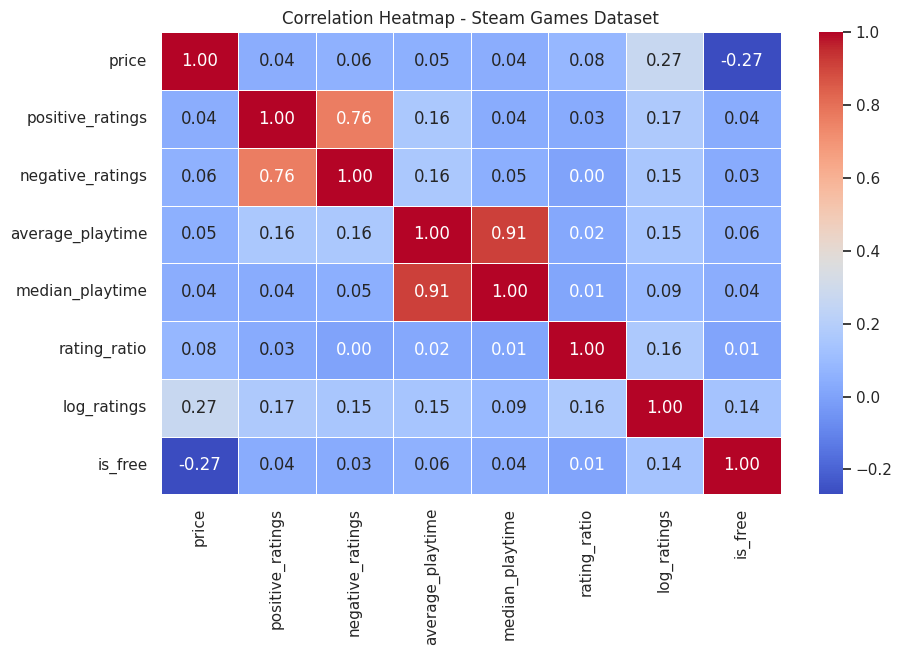

In [38]:
plt.figure(figsize=(10,6))

cols = [
    "price",
    "positive_ratings",
    "negative_ratings",
    "average_playtime",
    "median_playtime",
    "rating_ratio",
    "log_ratings",
    "is_free"
]

corr = df[cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap - Steam Games Dataset")
plt.show()

W pierwszej wersji projektu zastosowano cechy pochodne, takie jak rating_ratio, total_ratings oraz log_ratings, które były bezpośrednio lub pośrednio oparte na liczbie pozytywnych i negatywnych ocen użytkowników. W trakcie analizy okazało się, że cechy te są zbyt silnie powiązane ze zmienną docelową, co prowadziło do zjawiska data leakage. W efekcie modele uzyskiwały nienaturalnie wysokie wyniki dokładności (nawet powyżej 0.99), które nie odzwierciedlały rzeczywistej zdolności predykcyjnej modelu, lecz wynikały z „podpowiedzi” zawartych w danych wejściowych.

In [39]:
df["is_free"] = (df["price"] == 0).astype(int)
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year
df["game_age"] = 2025 - df["release_year"]
df["has_achievements"] = (df["achievements"] > 0).astype(int)
df["is_adult"] = (df["required_age"] >= 18).astype(int)

In [40]:
X_new = df[
    [
        "price",
        "average_playtime",
        "median_playtime",
        "is_free",
        "game_age",
        "has_achievements",
        "is_adult"
    ]
]

In [41]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

In [42]:
scaler = StandardScaler()

X_train_new_scaled = scaler.fit_transform(X_train_new)
X_test_new_scaled = scaler.transform(X_test_new)

In [43]:
lr_new = LogisticRegression(max_iter=1000)
lr_new.fit(X_train_new_scaled, y_train_new)
pred_lr_new = lr_new.predict(X_test_new_scaled)
acc_lr_new = accuracy_score(y_test_new, pred_lr_new)
acc_lr_new

0.7663896583564174

In [50]:
rf_new = RandomForestClassifier(random_state=42)
rf_new.fit(X_train_new_scaled, y_train_new)
pred_rf_new = rf_new.predict(X_test_new_scaled)
acc_rf_new = accuracy_score(y_test_new, pred_rf_new)
acc_rf_new

0.7708217913204063

In [60]:
grid_new = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_new.fit(X_train_new_scaled, y_train_new)
best_new = grid_new.best_estimator_
pred_best_new = best_new.predict(X_test_new_scaled)
acc_best_new = accuracy_score(y_test_new, pred_best_new)
acc_best_new

0.7806094182825485

In [51]:
print("Logistic Regression (X_new):", acc_lr_new)
print("Random Forest (X_new):", acc_rf_new)
print("GridSearch:", acc_best_new)

Logistic Regression (X_new): 0.7663896583564174
Random Forest (X_new): 0.7708217913204063
GridSearch: 0.7806094182825485


In [52]:
pred_best_new = best_new.predict(X_test_new)

acc_best_new = accuracy_score(y_test_new, pred_best_new)
prec_best_new = precision_score(y_test_new, pred_best_new)
f1_best_new = f1_score(y_test_new, pred_best_new)

print("Accuracy:", acc_best_new)
print("Precision:", prec_best_new)
print("F1-score:", f1_best_new)

Accuracy: 0.5034164358264082
Precision: 0.5034164358264082
F1-score: 0.6696965974695983


In [61]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "GridSearch RF"
    ],
    "Old features": [
        acc_feat,
        acc_rf_old,
        acc_best_old
    ],
    "New features": [
        acc_lr_new,
        acc_rf_new,
        acc_best_new
    ]
})

results

,Model,Old features,New features
0,Logistic Regression,0.993167,0.766390
1,Random Forest,0.998707,0.770822
2,GridSearch RF,0.997045,0.780609


In [57]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "F1-score"],
    "Old features": [
        acc_best_old,
        prec_best_old,
        f1_best_old
    ],
    "New features": [
        acc_best_new,
        prec_best_new,
        f1_best_new
    ]
})

comparison

,Metric,Old features,New features
0,Accuracy,0.997045,0.503416
1,Precision,0.994526,0.503416
2,F1-score,0.997073,0.669697


            Feature  Importance
6          is_adult      0.0037
3           is_free      0.0215
5  has_achievements      0.0595
1  average_playtime      0.2195
2   median_playtime      0.2232
0             price      0.2342
4          game_age      0.2384


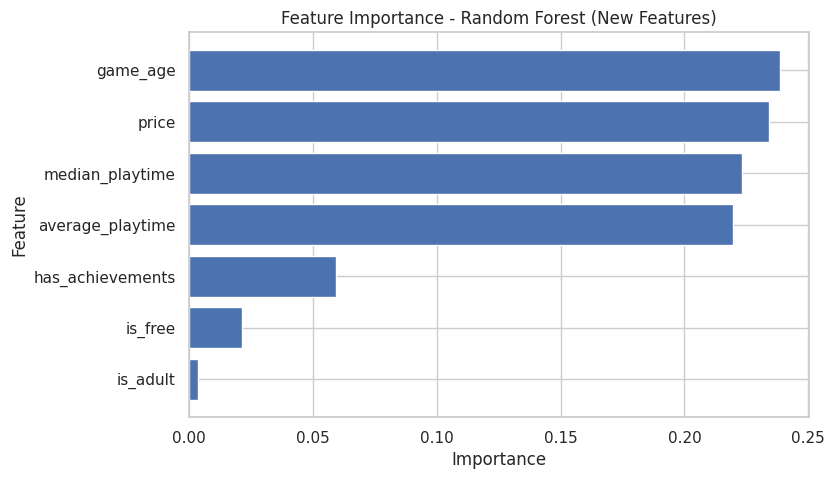

In [55]:
importances_new = rf_new.feature_importances_

feature_importance_new = pd.DataFrame({
    "Feature": X_new.columns,
    "Importance": importances_new
})

feature_importance_new = feature_importance_new.sort_values(
    by="Importance",
    ascending=True
)

feature_importance_new["Importance"] = feature_importance_new["Importance"].round(4)
print(feature_importance_new)

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance_new["Feature"],
    feature_importance_new["Importance"]
)
plt.title("Feature Importance - Random Forest (New Features)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [58]:
coefficients_new = lr_new.coef_[0]

coef_df_new = pd.DataFrame({
    "Feature": X_new.columns,
    "Coefficient": coefficients_new
})

plus_new = coef_df_new[
    coef_df_new["Coefficient"] > 0
].sort_values("Coefficient", ascending=False)

minus_new = coef_df_new[
    coef_df_new["Coefficient"] < 0
].sort_values("Coefficient")

print("CECHY ZWIĘKSZAJĄCE SZANSĘ SUKCESU:")
display(plus_new)
print("\nCECHY ZMNIEJSZAJĄCE SZANSĘ SUKCESU:")
display(minus_new)

CECHY ZWIĘKSZAJĄCE SZANSĘ SUKCESU:


,Feature,Coefficient
1,average_playtime,5.260909
2,median_playtime,3.952019
4,game_age,1.020934
0,price,0.651844
3,is_free,0.571109
5,has_achievements,0.493602
6,is_adult,0.101795



CECHY ZMNIEJSZAJĄCE SZANSĘ SUKCESU:


,Feature,Coefficient
